# Exploratory Data Analysis

In [222]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import variation
import seaborn as sns
import math

In [16]:
# Display all rows and columns in the DataFrame
# Comment if effect unwanted
pd.set_option('display.max_rows', None)  # No limit on number of rows
pd.set_option('display.max_columns', None)  # No limit on number of columns
pd.set_option('display.width', None)  # Auto-adjust the width
pd.set_option('display.max_colwidth', None)  # Show full content of each column

## Data Loading and Initial Inspection

In [2]:
# Load the Data Matrix, Feature Metadata, Acquisition List, and Exogenous Standards 
data_matrix = pd.read_csv("./data/input/internship_data_matrix.csv")
feature_metadata = pd.read_csv("./data/input/internship_feature_metadata.csv")
acquisition_list = pd.read_csv("./data/input/intership_acquisition_list.csv")
exogenous_stds = pd.read_csv("./data/input/exogenous_standards.csv")

In [3]:
# Inspect first few rows and shape to get an overview of the structure
display(data_matrix.head(), data_matrix.shape)
display(feature_metadata.head(), feature_metadata.shape)
display(acquisition_list.head(), acquisition_list.shape)
display(exogenous_stds.head(), exogenous_stds.shape)

,sample,FT-000,FT-001,FT-002,FT-003,FT-004,FT-005,FT-006,FT-007,FT-008,...,FT-242,FT-243,FT-244,FT-245,FT-246,FT-247,FT-248,FT-249,FT-250,FT-251
0,20241106-297-Blank1,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
1,20241106-297-Blank2,0.0,0.000000,0.0,5.770641,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,3.534493,0.0,0.0,0.0
2,20241106-297-Blank3,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,6.469501,0.0,0.0,0.0
3,20241106-297-Blank4,0.0,5.497865,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
4,20241106-297-Blank5,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0


(124, 253)

,feature,mz,mz max,mz min,mz std,rt,rt end,rt max,rt min,rt start,rt std
0,FT-000,359.108768,359.130591,359.090122,0.010955,543.846374,561.270879,546.697803,539.941156,528.714227,1.683901
1,FT-001,357.109546,357.130018,357.091871,0.010668,543.839157,563.021530,546.948017,540.038924,528.530311,1.662290
2,FT-002,889.649931,889.702216,889.601547,0.025552,609.099742,627.717251,611.746501,606.426553,596.789046,1.324647
3,FT-003,355.111928,355.132772,355.093653,0.010508,543.995269,566.951285,547.164503,540.681882,526.943213,1.609071
4,FT-004,888.645365,888.696941,888.600202,0.026161,609.255652,632.996442,612.008732,606.778809,595.461688,1.254684


(252, 11)

,sample,class,id,order,batch
0,20241106-297-Blank1,B,20241106-297-Blank1,1,1
1,20241106-297-Blank2,B,20241106-297-Blank2,2,1
2,20241106-297-Blank3,B,20241106-297-Blank3,3,1
3,20241106-297-Blank4,B,20241106-297-Blank4,102,1
4,20241106-297-Blank5,B,20241106-297-Blank5,103,1


(124, 5)

,compound_id,mz,Retention_time
0,GU4,886.40,610
1,GU5,1048.45,753
2,GU14,1253.96,1500
3,GU15,1334.99,1551


(4, 3)

Initial inspection of the data:
- Data Matrix (N, M): peak areas of the different samples measured in the experiment, calculated as the integration of the chromatographic peaks curve in the time domain buond by peak start and end. IT represents our quantitative measure, used to quantify presence of a molecule. --> N = 124 samples, M = 253 (including 252 features and one column for sample ID).
- Feature Metadata (M, K): descriptors for each feature of the samples of interest, i.e. for each chromatographic peak, including mass to charge ratio (mean, max, min, std), retention time (mean, start, end, max, mix, std) --> M = 252 features, K = 11 descriptors.
- Acquisition List (N, D): sample metadata including batch and run order --> N = 124 samples, D = 5 descriptors.
- Exogenous Standards (S, k): descriptors for each feature of exogenous standards --> S = 4 features, k = 2 descriptors.

## Preliminary Data Checks

In [4]:
# Check consistency of data shapes
print("Correct number of samples N:", data_matrix.shape[0]==acquisition_list.shape[0])
print("Correct number of features M:", data_matrix.shape[1]==feature_metadata.shape[0])

Correct number of samples N: True
Correct number of features M: False


In [5]:
# Ensure consistency
data_matrix = data_matrix.set_index('sample')
feature_metadata = feature_metadata.set_index('feature')
acquisition_list = acquisition_list.set_index('sample')
exogenous_stds = exogenous_stds.set_index('compound_id')

In [6]:
display(data_matrix.head(), data_matrix.shape)
display(feature_metadata.head(), feature_metadata.shape)
display(acquisition_list.head(), acquisition_list.shape)
display(exogenous_stds.head(), exogenous_stds.shape)

,FT-000,FT-001,FT-002,FT-003,FT-004,FT-005,FT-006,FT-007,FT-008,FT-009,...,FT-242,FT-243,FT-244,FT-245,FT-246,FT-247,FT-248,FT-249,FT-250,FT-251
sample,,,,,,,,,,,,,,,,,,,,,
20241106-297-Blank1,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
20241106-297-Blank2,0.0,0.000000,0.0,5.770641,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,3.534493,0.0,0.0,0.0
20241106-297-Blank3,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,6.469501,0.0,0.0,0.0
20241106-297-Blank4,0.0,5.497865,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
20241106-297-Blank5,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0


(124, 252)

,mz,mz max,mz min,mz std,rt,rt end,rt max,rt min,rt start,rt std
feature,,,,,,,,,,
FT-000,359.108768,359.130591,359.090122,0.010955,543.846374,561.270879,546.697803,539.941156,528.714227,1.683901
FT-001,357.109546,357.130018,357.091871,0.010668,543.839157,563.021530,546.948017,540.038924,528.530311,1.662290
FT-002,889.649931,889.702216,889.601547,0.025552,609.099742,627.717251,611.746501,606.426553,596.789046,1.324647
FT-003,355.111928,355.132772,355.093653,0.010508,543.995269,566.951285,547.164503,540.681882,526.943213,1.609071
FT-004,888.645365,888.696941,888.600202,0.026161,609.255652,632.996442,612.008732,606.778809,595.461688,1.254684


(252, 10)

,class,id,order,batch
sample,,,,
20241106-297-Blank1,B,20241106-297-Blank1,1,1
20241106-297-Blank2,B,20241106-297-Blank2,2,1
20241106-297-Blank3,B,20241106-297-Blank3,3,1
20241106-297-Blank4,B,20241106-297-Blank4,102,1
20241106-297-Blank5,B,20241106-297-Blank5,103,1


(124, 4)

,mz,Retention_time
compound_id,,
GU4,886.40,610
GU5,1048.45,753
GU14,1253.96,1500
GU15,1334.99,1551


(4, 2)

In [7]:
print("Correct number of samples N:", data_matrix.shape[0]==acquisition_list.shape[0])
print("Correct number of features M:", data_matrix.shape[1]==feature_metadata.shape[0])

Correct number of samples N: True
Correct number of features M: True


In [8]:
# Check for missing values in our data
print("Missing values in Data Matrix:", data_matrix.isnull().values.any())
print("Missing values in Feature Metadata:", feature_metadata.isnull().values.any())

Missing values in Data Matrix: False
Missing values in Feature Metadata: False


In [9]:
# Check for negative values in our data
print("Negative values in Data Matrix:", (data_matrix < 0).values.any())
print("Neagtive values in Feature Metadata:", (feature_metadata < 0).values.any())

Negative values in Data Matrix: False
Neagtive values in Feature Metadata: False


Data is ready for further analysis.

## Basic Data Exploration

Features Detected in each Sample

In [79]:
# Are there any samples that do not have any features detected?
print("Any samples with no features?:", ((data_matrix > 0).sum(axis=1)==0).any())

# Number of features detected for each sample type
data_matrix_types = data_matrix.copy()

# Define a function to assign sample types based on index names
def assign_sample_type(row_name):
    if 'LMU' in row_name:
        return 'Benign Disease'
    elif 'French' in row_name:
        return 'Lung Cancer'
    elif 'Dunn' in row_name:
        return 'Healthy'
    elif 'Experimental' in row_name:
        return 'Exogenous Standard'
    elif 'Blank' in row_name:
        return 'Blank'
    elif 'Diluted-QC' in row_name or 'Diluted_QC' in row_name or 'QC' in row_name:
        return 'QC'
    else:
        return np.nan  # If no match is found, you can return NaN or another value

# Apply the function to the index and create the new "Sample Type" column
data_matrix_types['Sample Type'] = data_matrix_types.index.to_series().apply(assign_sample_type)

# Group by by the sample type
grouped = data_matrix_types.groupby('Sample Type')

Any samples with no features?: False


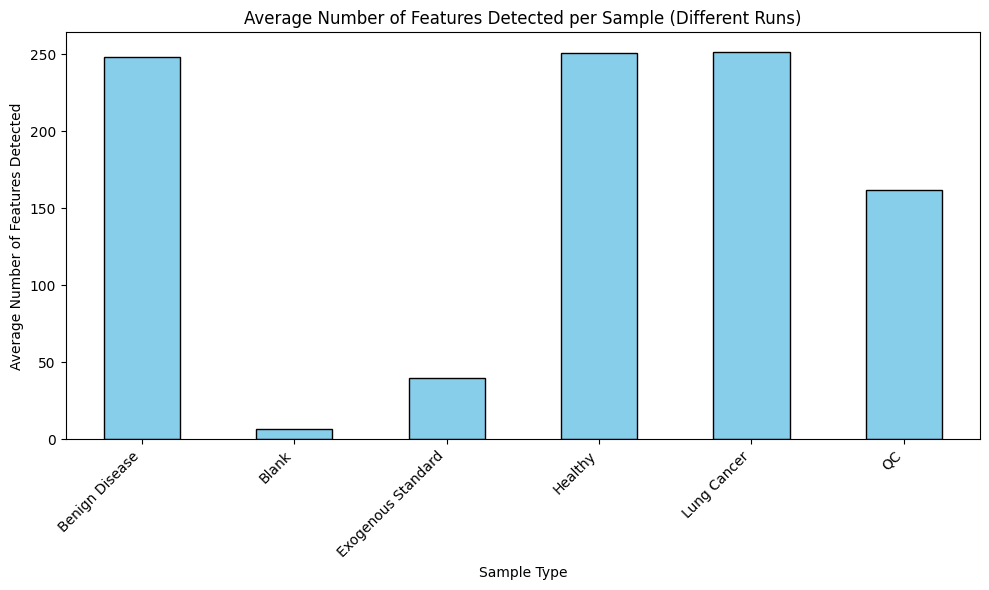

In [80]:
# Plot the average number of detected features (features for which peak area is > 0) for each sample type
average_features_detected = grouped.apply(lambda group: (group > 0).sum(axis=1)).groupby('Sample Type').mean()

# Plot the average number of features detected for each sample type
plt.figure(figsize=(10, 6))
average_features_detected.plot(kind='bar', color='skyblue', edgecolor='black')

# Customize the plot
plt.title('Average Number of Features Detected per Sample (Different Runs)')
plt.xlabel('Sample Type')
plt.ylabel('Average Number of Features Detected')
plt.xticks(rotation=45, ha='right')  # Rotate sample type labels for better visibility
plt.tight_layout()  # Ensure the plot fits within the figure area

# Display the plot
plt.show()

Distribution of Mass to Charge Ratio and Retention Time across detected Features

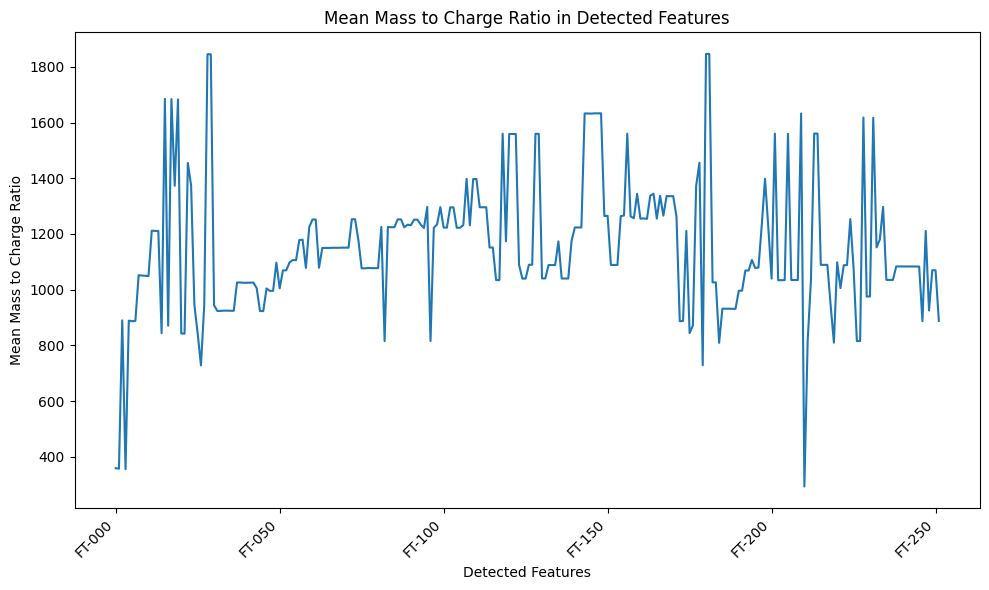

In [81]:
# Plot the mass to charge ratio across detected features
plt.figure(figsize=(10, 6))
feature_metadata.mz.plot()

# Customize the plot
plt.title('Mean Mass to Charge Ratio in Detected Features')
plt.xlabel('Detected Features')
plt.ylabel('Mean Mass to Charge Ratio')
plt.xticks(rotation=45, ha='right')  # Rotate sample type labels for better visibility
plt.tight_layout()  # Ensure the plot fits within the figure area

# Display the plot
plt.show()

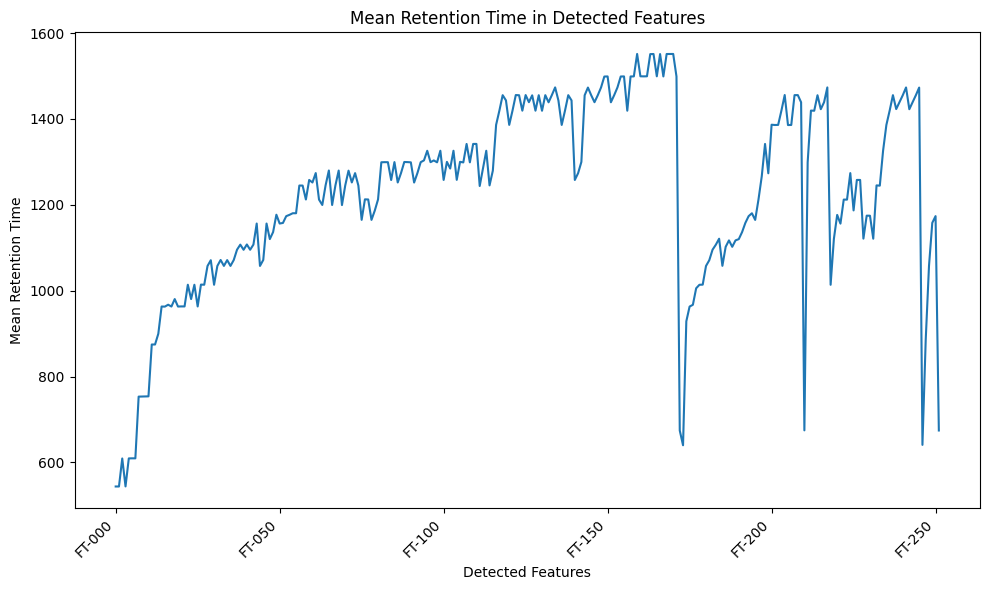

In [82]:
# Plot the retention time across detected features
plt.figure(figsize=(10, 6))
feature_metadata.rt.plot()

# Customize the plot
plt.title('Mean Retention Time in Detected Features')
plt.xlabel('Detected Features')
plt.ylabel('Mean Retention Time')
plt.xticks(rotation=45, ha='right')  # Rotate sample type labels for better visibility
plt.tight_layout()  # Ensure the plot fits within the figure area

# Display the plot
plt.show()

## Quantitative Quality Criteria

### 1. Coefficient of Variation (CV)

The **coefficient of variation (CV)** is an important metric used to measure the **variability** of a set of values relative to the mean. It is particularly useful in assessing **technical variability** in experiments like LC-MS, where consistent measurement is crucial. CV is calculated as:

<img src="./images/CV.png" alt="Alt Text" width="300"/>

In peak area data from LC-MS experiments, **CV** allows to quantify the variability across replicate measurements of the same sample, helping evaluate the precision of the analytical method.

Here we will:
- Compute the CV for each feature to measure variability in peak areas across QC samples. This will help identify features with high technical variability.
- Visualize the CV across features using a histogram.

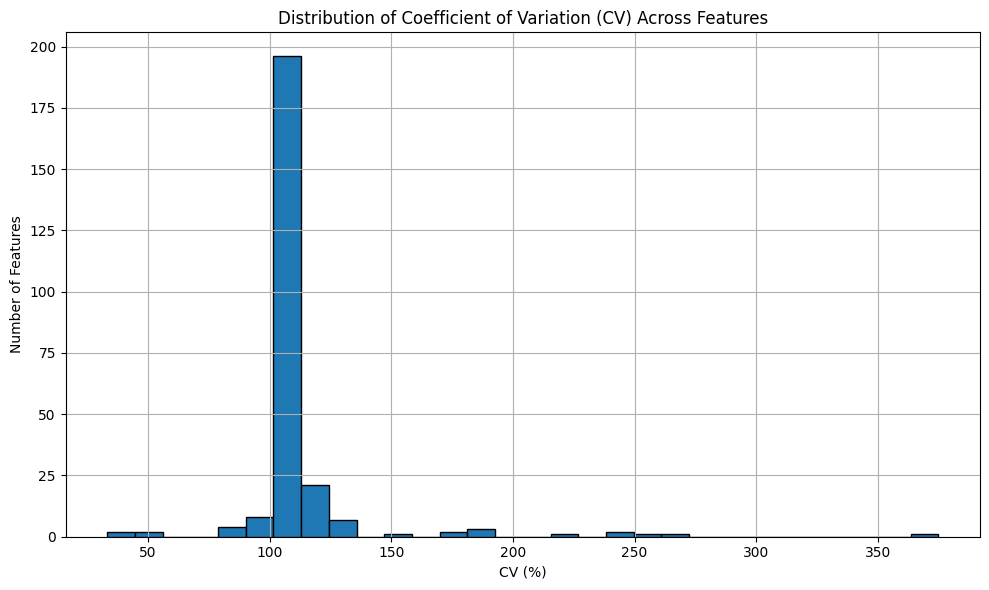

In [146]:
# QC samples
qc_data = data_matrix_types[data_matrix_types["Sample Type"] == "QC"]

# Drop the sample type column
qc_data_features = qc_data.drop(columns="Sample Type")

# Compute CV for each feature
cv = (qc_data_features.std() / qc_data_features.mean()) * 100

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(cv, bins=30, edgecolor='black')
plt.title("Distribution of Coefficient of Variation (CV) Across Features")
plt.xlabel("CV (%)")
plt.ylabel("Number of Features")
plt.grid(True)
plt.tight_layout()
plt.show()

Most features have a CV of 100 ??

## 2. Dispersion Ratio (D-Ratio)

The D-ratio represents the relation of the statistical dispersion of the QCs to the dispersion of the biological test samples. The D-ratio is calculated by dividing the technical variation by the total observed variation; this is the sum of technical and biological variation. Here, the variance of the QCs (𝜎2𝑖,𝑄⁢𝐶) approximates the technical variation, and the variance of the biological test samples (𝜎2𝑖,𝑠⁢𝑎⁢𝑚⁢𝑝⁢𝑙⁢𝑒) approximates the overall biological variation.

<img src="./images/D_ratio.png" alt="Alt Text" width="300"/>

A D-ratio close to 0% would be a perfect measurement, where the technical variance is zero and all observed variance originates from the biological variation. On the other hand, a D-ratio of 100% would be the worst possible measurement, where there is no biological variation and only noise is detected. A metabolite, where 𝜎2𝑖,𝑠⁢𝑎⁢𝑚⁢𝑝⁢𝑙⁢𝑒 ≫ 𝜎2𝑖,𝑄⁢𝐶 with a D-ratio below 50%, is preferred.

{'whiskers': [<matplotlib.lines.Line2D at 0x14e96c8b0>,
 'caps': [<matplotlib.lines.Line2D at 0x14e96cdf0>,
 'boxes': [<matplotlib.lines.Line2D at 0x14e96c610>],
 'medians': [<matplotlib.lines.Line2D at 0x14e975370>],
 'fliers': [<matplotlib.lines.Line2D at 0x14e975610>],
 'means': []}

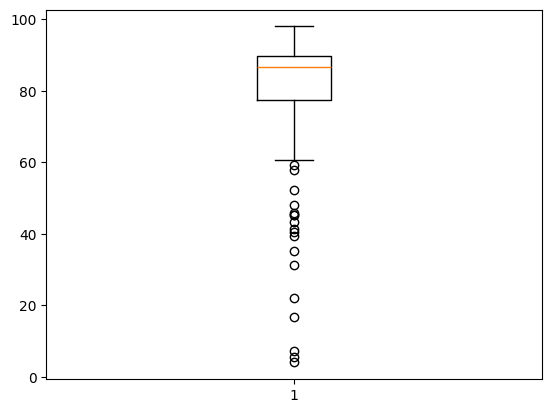

In [152]:
# i = metabolite, i.e. feature
# we want the d-ratio for each feature

# Technical Variation (variance of the QCs) for each metabolite (or feature)
std = grouped.std()
technical_variation = std[std.index=='QC'].values.flatten()

# Total Variation (biological variation + technical variation)
var = grouped.var()
total_variation = np.sqrt(var[var.index=='QC'].values.flatten() + var[var.index=='Lung Cancer'].values.flatten() + var[var.index=='Benign Disease'].values.flatten() + var[var.index=='Healthy'].values.flatten())

# D-ratio for each metabolite
d_ratio = technical_variation*100/total_variation

plt.boxplot(d_ratio)

Very high d-ratio??

## 3. Relative Standard Deviation (RSD)

The RSD is a widely used metric, which is calculated for each metabolite i within the QCs by dividing the standard deviation 𝜎𝑖,𝑄⁢𝐶 by the arithmetic mean m𝑖,𝑄⁢𝐶. This leads to a unitless and standardized measure comparable among all detectable metabolites.

<img src="./images/RSD.png" alt="Alt Text" width="300"/>

A typically accepted RSD threshold for metabolites in biomarker discovery should be below 20% for LC-MS.

{'whiskers': [<matplotlib.lines.Line2D at 0x14fa62dc0>,
 'caps': [<matplotlib.lines.Line2D at 0x14fa75340>,
 'boxes': [<matplotlib.lines.Line2D at 0x14fa62b20>],
 'medians': [<matplotlib.lines.Line2D at 0x14fa75880>],
 'fliers': [<matplotlib.lines.Line2D at 0x14fa75b20>],
 'means': []}

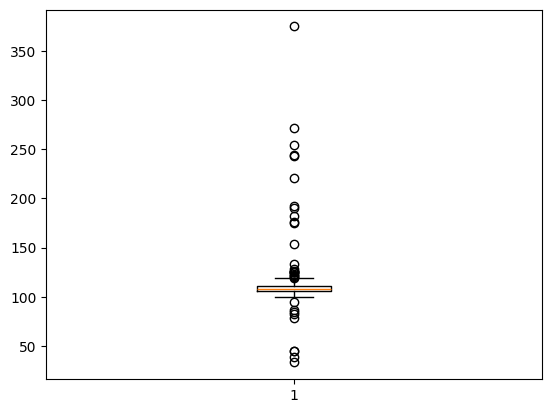

In [156]:
QC_std = std[std.index=='QC'].values.flatten()

mean = grouped.mean()
QC_mean = mean[mean.index=='QC'].values.flatten()

rsd = QC_std*100/QC_mean

plt.boxplot(rsd)

Way too high RSD???

## Identification of Potential Isomers, Isotopes, and Adducts

### 1. Isomers

In this part, we will visualize mass to charge ratios to identify isomers, i.e. molecules that have the same mass but different retention times.

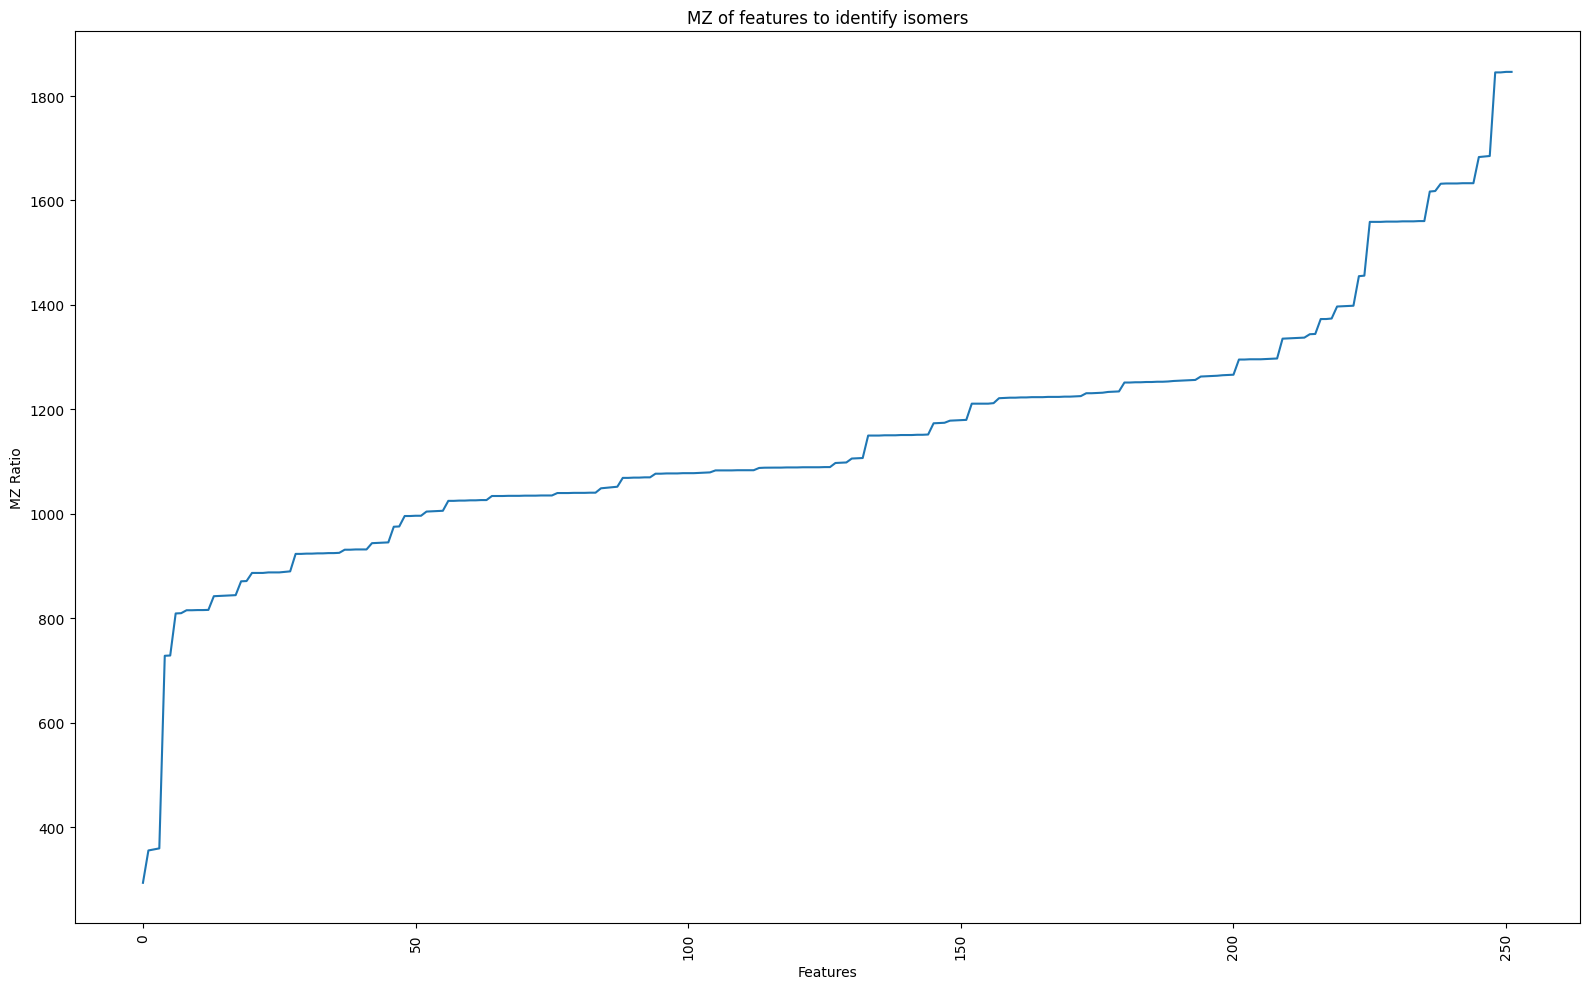

In [202]:
# Sort the dataframe for M/Z
mz = feature_metadata['mz']

# Sort from low to high for easier comparison
mz = mz.sort_values(ascending=True)

mz.reset_index(drop=True).plot(kind='line', figsize=(16, 10))
plt.xlabel("Features")  
plt.ylabel("MZ Ratio")  
plt.title("MZ of features to identify isomers")     
plt.xticks(rotation=90)     
plt.tight_layout()          
plt.show()

As we can see, many features have very similar mass to charge ratios, indicating that some metabolites are isomers.

Now, let us group isomers together, such that we can investigate if there is any correlation in terms of peak areas between isomers.

In [ ]:
# Identify Isomers

tolerance = 5  
isomer_labels = {}  # To store labels
visited = set()
isomer_id = 1

for index_i, mz_i in feature_metadata.mz.items():
    if index_i in visited:
        continue
    
    # Find all isomers within tolerance
    group = []
    for index_j, mz_j in feature_metadata.mz.items():
        if abs(mz_j - mz_i) <= tolerance:
            group.append(index_j)
    
    # Label all in the group
    for idx in group:
        isomer_labels[idx] = f"Isomer{isomer_id}"
        visited.add(idx)
    
    isomer_id += 1

# Add to dataframe
feature_metadata['Isomer'] = feature_metadata.index.map(isomer_labels)

In [219]:
# Prepare: get mapping from feature to isomer group
feature_to_isomer = feature_metadata['Isomer'].dropna()

# Initialize dictionary to store correlations per isomer group
isomer_correlations = {}

# For each isomer group
for isomer_group, features in feature_to_isomer.groupby(feature_to_isomer).groups.items():
    # Subset the data_matrix for the features in this isomer group
    isomer_data = data_matrix[features]
    
    # Only compute correlation if more than 1 feature in group
    if isomer_data.shape[1] > 1:
        # Compute the correlation matrix between features
        corr_matrix = isomer_data.corr()
        isomer_correlations[isomer_group] = corr_matrix


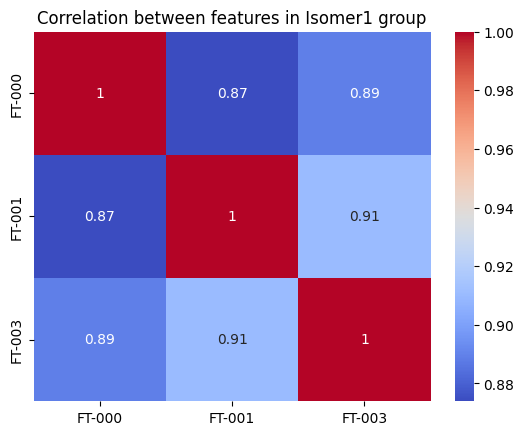

In [228]:
# Visualize the correlation between isomers, for example Isomer1
sns.heatmap(isomer_correlations['Isomer1'], annot=True, cmap='coolwarm')
plt.title('Correlation between features in Isomer1 group')
plt.show()

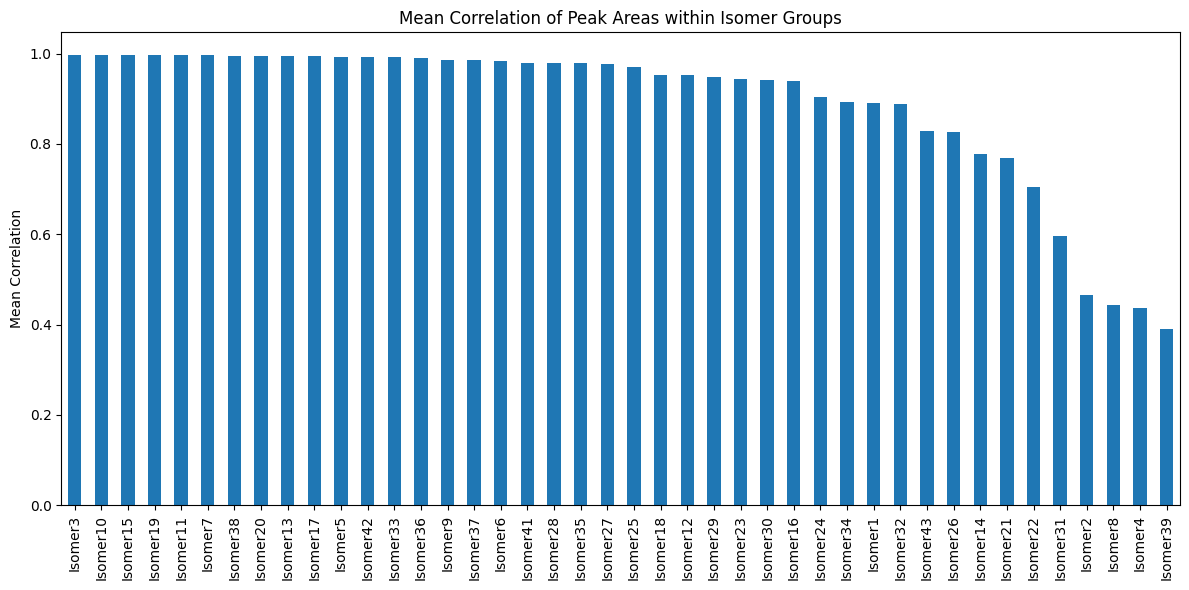

In [227]:
# Compute the mean correlation in each isomer group
mean_correlations = {}

for isomer_name, corr_matrix in isomer_correlations.items():
    if corr_matrix.shape[0] > 1:  # Only meaningful if there's more than one feature
        # Extract the lower triangle without the diagonal
        mask = ~np.eye(corr_matrix.shape[0], dtype=bool)
        values = corr_matrix.values[mask]
        mean_corr = np.nanmean(values)  # nanmean in case of NaNs
        mean_correlations[isomer_name] = mean_corr

# Visualize mean correlation in each isomer group
mean_corr_series = pd.Series(mean_correlations).sort_values(ascending=False)

# Plot
plt.figure(figsize=(12, 6))
mean_corr_series.plot(kind='bar')
plt.ylabel('Mean Correlation')
plt.title('Mean Correlation of Peak Areas within Isomer Groups')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### 2. Isotopes (or Adducts)

In this part, we visualize the retention time of features, to identify isotopes, i.e. molecules that have same retention time but different mass.

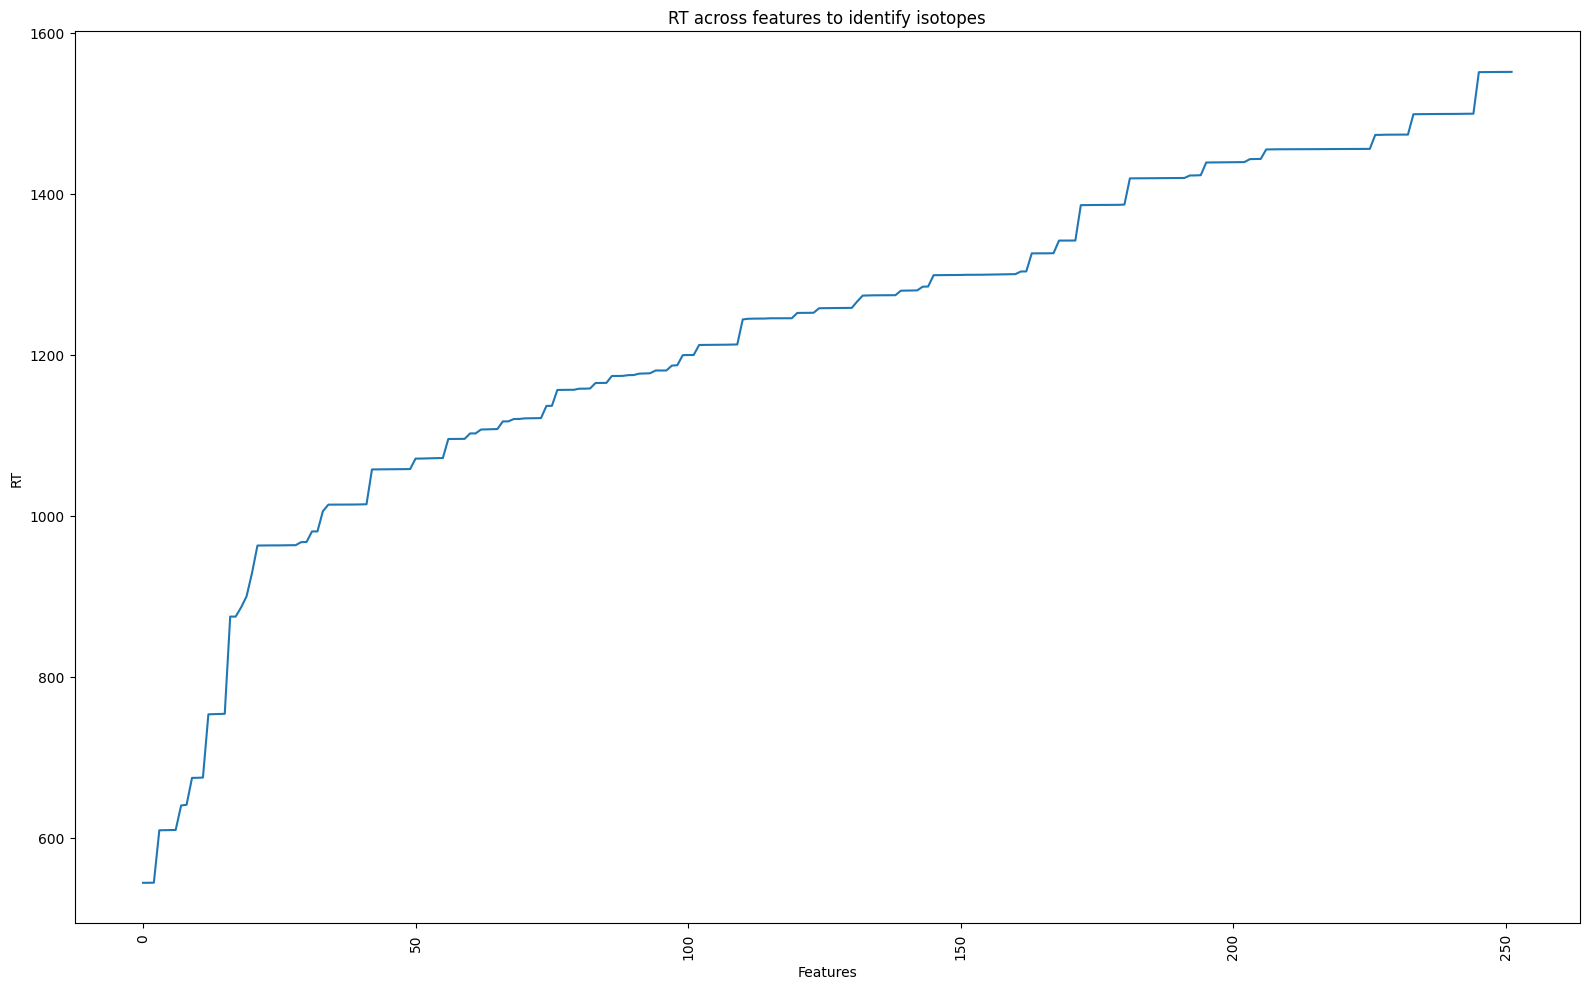

In [223]:
# Sort the dataframe for RT
rt = feature_metadata['rt']

# Sort from low to high for easier comparison
rt = rt.sort_values(ascending=True)

rt.reset_index(drop=True).plot(kind='line', figsize=(16, 10))
plt.xlabel("Features")  
plt.ylabel("RT")  
plt.title("RT across features to identify isotopes")     
plt.xticks(rotation=90)     
plt.tight_layout()          
plt.show()

As we can see, some features share similar retention times, indicating that some metabolites are isotopes.

Now, let us group isotopes together, such that we can investigate if there is any correlation in terms of peak areas between isotopes.

In [231]:
# Identify Isotopes

tolerance = 5  
isotope_labels = {}  # To store labels
visited = set()
isotope_id = 1

for index_i, rt_i in feature_metadata.rt.items():
    if index_i in visited:
        continue
    
    # Find all isotopes within tolerance
    group = []
    for index_j, rt_j in feature_metadata.rt.items():
        if abs(rt_j - rt_i) <= tolerance:
            group.append(index_j)
    
    # Label all in the group
    for idx in group:
        isotope_labels[idx] = f"Isotope{isotope_id}"
        visited.add(idx)
    
    isotope_id += 1

# Add to dataframe
feature_metadata['Isotope'] = feature_metadata.index.map(isotope_labels)

In [233]:
# Prepare: get mapping from feature to isotope group
feature_to_isotope = feature_metadata['Isotope'].dropna()

# Initialize dictionary to store correlations per isotope group
isotope_correlations = {}

# For each isotope group
for isotope_group, features in feature_to_isotope.groupby(feature_to_isotope).groups.items():
    # Subset the data_matrix for the features in this isotope group
    isotope_data = data_matrix[features]
    
    # Only compute correlation if more than 1 feature in group
    if isotope_data.shape[1] > 1:
        # Compute the correlation matrix between features
        corr_matrix = isotope_data.corr()
        isotope_correlations[isotope_group] = corr_matrix

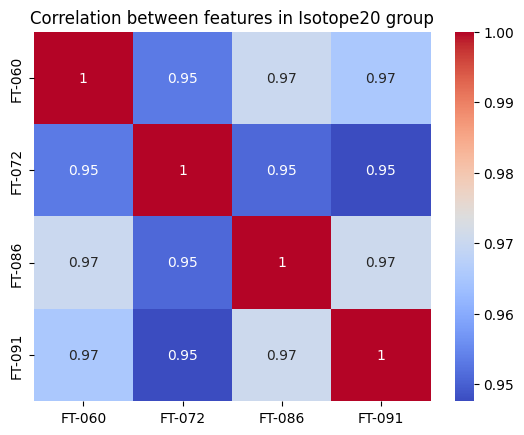

In [235]:
# Visualize the correlation between isotopes, for example Isotope
sns.heatmap(isotope_correlations['Isotope20'], annot=True, cmap='coolwarm')
plt.title('Correlation between features in Isotope20 group')
plt.show()

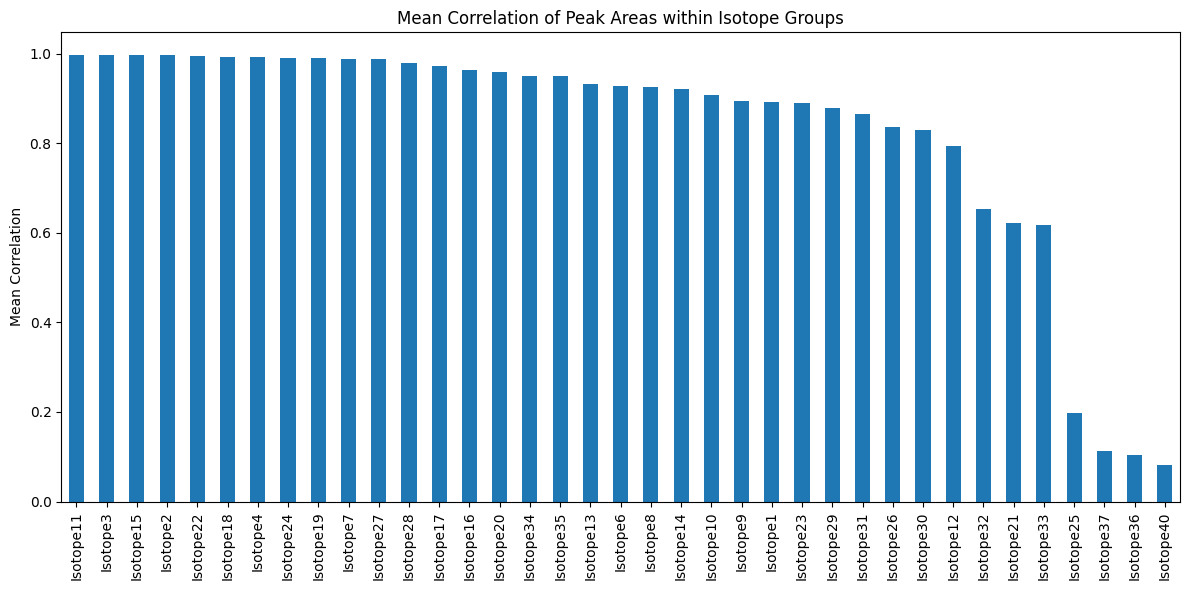

In [236]:
# Compute the mean correlation in each isotope group
mean_correlations = {}

for isotope_name, corr_matrix in isotope_correlations.items():
    if corr_matrix.shape[0] > 1:  # Only meaningful if there's more than one feature
        # Extract the lower triangle without the diagonal
        mask = ~np.eye(corr_matrix.shape[0], dtype=bool)
        values = corr_matrix.values[mask]
        mean_corr = np.nanmean(values)  # nanmean in case of NaNs
        mean_correlations[isotope_name] = mean_corr

# Visualize mean correlation in each isotope group
mean_corr_series = pd.Series(mean_correlations).sort_values(ascending=False)

# Plot
plt.figure(figsize=(12, 6))
mean_corr_series.plot(kind='bar')
plt.ylabel('Mean Correlation')
plt.title('Mean Correlation of Peak Areas within Isotope Groups')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()